# ImageNet-100-C → Sequential Stream Builder




**What this notebook does:**
1. Builds 3 sequential stream CSV files (abrupt, gradual, driving) from the Imagenet100C dataset
2. Validates stream statistics and visualizes shift boundaries



---
## Cell 1 — Configuration


In [ ]:
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Extract Data to Local Colab Disk (for fast loading)
ZIP_PATH = '/content/drive/MyDrive/DL_project/ImageNet-100-C.zip' #<---
LOCAL_EXTRACT_DIR = '/content/data'
IMAGENET_C_DIR = f"{LOCAL_EXTRACT_DIR}/ImageNet-100-C"

os.makedirs(LOCAL_EXTRACT_DIR, exist_ok=True)
if not os.path.exists(IMAGENET_C_DIR):
    print(f"Extracting {ZIP_PATH} to local Colab storage...")
    !unzip -q "{ZIP_PATH}" -d "{LOCAL_EXTRACT_DIR}"
    print("Extraction complete.")

# 3. Configure Outputs to Save to Drive
STREAM_OUT_DIR = '/content/drive/MyDrive/DL_project/final_streams/stream_seed3' # <-------
RANDOM_SEED    = 42

os.makedirs(STREAM_OUT_DIR, exist_ok=True)
print(f'\nOutput directory ready: {STREAM_OUT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Output directory ready: /content/drive/MyDrive/DL_project/final_streams/stream_seed3


---
## Cell 2 — Verifying
 Generated Data
Checks which corruptions and severities actually exist on disk, and reports image counts.

In [ ]:
import os
from collections import defaultdict

IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.ppm', '.bmp')

def count_images(path):
    total = 0
    for root, _, files in os.walk(path):
        total += sum(1 for f in files if f.lower().endswith(IMG_EXTENSIONS))
    return total

inventory = defaultdict(dict)

if not os.path.isdir(IMAGENET_C_DIR):
    raise FileNotFoundError(f'Cannot find IMAGENET_C_DIR: {IMAGENET_C_DIR}')

for corruption in sorted(os.listdir(IMAGENET_C_DIR)):
    c_path = os.path.join(IMAGENET_C_DIR, corruption)
    if not os.path.isdir(c_path):
        continue
    for severity in sorted(os.listdir(c_path)):
        s_path = os.path.join(c_path, severity)
        if not os.path.isdir(s_path):
            continue
        n = count_images(s_path)
        inventory[corruption][severity] = n

print(f"{'Corruption':<20} | {'Severity':<8} | Images")
print('-' * 42)
for corruption, severities in inventory.items():
    for sev, count in sorted(severities.items()):
        status = '✅' if count > 0 else '❌ EMPTY'
        print(f"{corruption:<20} | {sev:<8} | {count:>6}  {status}")

available_corruptions = list(inventory.keys())
print(f"\nFound {len(available_corruptions)} corruption types: {available_corruptions}")

Corruption           | Severity | Images
------------------------------------------
brightness           | 1        |   5000  ✅
brightness           | 2        |   5000  ✅
brightness           | 3        |   5000  ✅
brightness           | 4        |   5000  ✅
brightness           | 5        |   5000  ✅
contrast             | 1        |   5000  ✅
contrast             | 2        |   5000  ✅
contrast             | 3        |   5000  ✅
contrast             | 4        |   5000  ✅
contrast             | 5        |   5000  ✅
defocus_blur         | 1        |   5000  ✅
defocus_blur         | 2        |   5000  ✅
defocus_blur         | 3        |   5000  ✅
defocus_blur         | 4        |   5000  ✅
defocus_blur         | 5        |   5000  ✅
elastic_transform    | 1        |   5000  ✅
elastic_transform    | 2        |   5000  ✅
elastic_transform    | 3        |   5000  ✅
elastic_transform    | 4        |   5000  ✅
elastic_transform    | 5        |   5000  ✅
fog                  | 1        |   

---
## Cell 3 — Stream Builder Core Function

In [ ]:
import csv
import random

random.seed(RANDOM_SEED)

def build_sequential_stream(imagenet_c_dir, stream_config, out_csv):
    rows = []
    position = 0
    skipped_blocks = []

    for (corruption, severity, n_images) in stream_config:
        severity = str(severity)
        block_dir = os.path.join(imagenet_c_dir, corruption, severity)

        if not os.path.isdir(block_dir):
            print(f'Skipping block ({corruption}, sev={severity}): directory not found.')
            skipped_blocks.append((corruption, severity))
            continue

        all_images = []
        for class_name in sorted(os.listdir(block_dir)):
            class_dir = os.path.join(block_dir, class_name)
            if not os.path.isdir(class_dir):
                continue
            for fname in os.listdir(class_dir):
                if fname.lower().endswith(IMG_EXTENSIONS):
                    all_images.append((os.path.join(class_dir, fname), class_name))

        if len(all_images) == 0:
            print(f'Skipping block ({corruption}, sev={severity}): 0 images found.')
            skipped_blocks.append((corruption, severity))
            continue

        n_actual = min(n_images, len(all_images))
        sampled = random.sample(all_images, n_actual)

        for i, (img_path, label) in enumerate(sampled):
            rows.append({
                'position':   position,
                'path':       img_path,
                'label':      label,
                'corruption': corruption,
                'severity':   severity,
                'is_shift':   1 if i == 0 else 0
            })
            position += 1

    if not rows:
        raise RuntimeError('Stream is empty — check your IMAGENET_C_DIR and stream_config corruptions.')

    with open(out_csv, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)

    n_shifts = sum(1 for r in rows if r['is_shift'] == 1)
    print(f'Written: {len(rows)} images | {n_shifts} shift boundaries → {out_csv}')
    return out_csv

print('Stream builder function loaded.')

Stream builder function loaded.


In [ ]:
# ── Random Seed Configuration ─────────────────────────────────────────────
# Run 1: RANDOM_SEED = 42
# Run 2: RANDOM_SEED = 123
# Run 3: RANDOM_SEED = 456

RANDOM_SEED = 456 # <--- changing this between runs

import random
import numpy as np
import torch

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f'Random seed set to: {RANDOM_SEED}')
print(f'All stream shuffles will use this seed.')

Random seed set to: 456
All stream shuffles will use this seed.


---
## Cell 4 — Defining Stream Configurations

Three streams, each testing a different behaviour:

| Stream | Purpose | What our code should do |
|--------|----------|--------------------|
| **Abrupt** | Hard shift between unrelated corruptions | Surprise term fires strongly; SRT is your key metric |
| **Gradual** | Severity ramps up within same corruption | Novelty term catches slow drift; Surprise stays quiet |
| **Driving** | Realistic day-of-driving scenario | Full code engagement; mirrors Karachi validation story |

In [ ]:
# # ── Stream 1: Abrupt Shifts ───────────────────────────────────────────────
# # 4 hard transitions between unrelated corruptions at fixed severity.
# # Ground truth for measuring Shift Recovery Time (SRT).
# ABRUPT_STREAM = [
#     ('fog',            3, 500),
#     ('gaussian_noise', 3, 500),
#     ('motion_blur',    3, 500),
#     ('frost',          3, 500),
# ]

# # ── Stream 2: Gradual Drift ───────────────────────────────────────────────
# # Severity ramps up within the same corruption family, then switches.
# # Tests if Temporal Anchor detects slow environmental change.
# GRADUAL_STREAM = [
#     ('brightness', 1, 300),
#     ('brightness', 2, 300),
#     ('brightness', 3, 300),
#     ('brightness', 4, 300),
#     ('fog',        1, 300),
#     ('fog',        3, 300),
#     ('fog',        5, 300),
# ]

# # ── Stream 3: Driving Scenario ────────────────────────────────────────────
# # Simulates a realistic drive: dawn → fog → highway → tunnel → rain.
# # This is your narrative anchor for the Karachi road scene motivation.
# DRIVING_STREAM = [
#     ('brightness',     2, 400),   # early morning / dawn light
#     ('fog',            3, 400),   # morning fog on highway
#     ('motion_blur',    2, 400),   # high-speed motorway
#     ('contrast',       4, 400),   # entering a tunnel
#     ('gaussian_noise', 3, 400),   # rain / sensor noise
# ]

# # ── NOTE: Only include corruptions you actually generated ─────────────────
# # Check the output of Cell 2 to confirm which ones are available.
# # Comment out any block whose corruption doesn't appear in available_corruptions.
# print('Stream configurations defined.')
# print(f'  Abrupt:  {sum(n for _,_,n in ABRUPT_STREAM)} images, {len(ABRUPT_STREAM)} shifts')
# print(f'  Gradual: {sum(n for _,_,n in GRADUAL_STREAM)} images, {len(GRADUAL_STREAM)} shifts')
# print(f'  Driving: {sum(n for _,_,n in DRIVING_STREAM)} images, {len(DRIVING_STREAM)} shifts')
ABRUPT_STREAM_LARGE = [
    ('fog',              3, 5000),
    ('gaussian_noise',   3, 5000),
    ('motion_blur',      3, 5000),
    ('frost',            3, 5000),
    ('contrast',         3, 5000),
    ('jpeg_compression', 3, 5000),
]


SEVERITY_ESCALATION_STREAM = [
    ('fog', 1, 3000),
    ('fog', 2, 3000),
    ('fog', 3, 3000),
    ('fog', 4, 3000),
    ('fog', 5, 3000),
]

DRIVING_STREAM = [
    ('brightness',     2, 3000),   # dawn
    ('fog',            4, 3000),   # heavy fog
    ('motion_blur',    2, 3000),   # highway
    ('contrast',       5, 3000),   # tunnel
    ('gaussian_noise', 3, 3000),   # rain
    ('snow',           3, 2000),   # winter conditions
    ('brightness',     5, 2000),   # harsh glare
]

print('Stream configurations defined.')

Stream configurations defined.


---
## Cell 5 — Build the Streams

In [ ]:
# print('Building streams...\n')

# abrupt_csv  = build_sequential_stream(IMAGENET_C_DIR, ABRUPT_STREAM_LARGE,  os.path.join(STREAM_OUT_DIR, 'stream_abrupt.csv'))
# gradual_csv = build_sequential_stream(IMAGENET_C_DIR, SEVERITY_ESCALATION_STREAM, os.path.join(STREAM_OUT_DIR, 'stream_gradual.csv'))
# driving_csv = build_sequential_stream(IMAGENET_C_DIR, DRIVING_STREAM, os.path.join(STREAM_OUT_DIR, 'stream_driving.csv'))

# print('\nDone.')

print('Building streams...\n')
print(f'Using random seed: {RANDOM_SEED}')

abrupt_csv  = build_sequential_stream(
    IMAGENET_C_DIR, ABRUPT_STREAM_LARGE,
    os.path.join(STREAM_OUT_DIR, f'stream_abrupt_seed{RANDOM_SEED}.csv')
)
gradual_csv = build_sequential_stream(
    IMAGENET_C_DIR, SEVERITY_ESCALATION_STREAM,
    os.path.join(STREAM_OUT_DIR, f'stream_gradual_seed{RANDOM_SEED}.csv')
)
driving_csv = build_sequential_stream(
    IMAGENET_C_DIR, DRIVING_STREAM,
    os.path.join(STREAM_OUT_DIR, f'stream_driving_seed{RANDOM_SEED}.csv')
)

Building streams...

Using random seed: 456
Written: 30000 images | 6 shift boundaries → /content/drive/MyDrive/DL_project/final_streams/stream_seed3/stream_abrupt_seed456.csv
Written: 15000 images | 5 shift boundaries → /content/drive/MyDrive/DL_project/final_streams/stream_seed3/stream_gradual_seed456.csv
Written: 19000 images | 7 shift boundaries → /content/drive/MyDrive/DL_project/final_streams/stream_seed3/stream_driving_seed456.csv


---
## Cell 6 — Validating and Inspecting Streams
Sanity-check of the CSVs: corruption block sizes, shift positions, class balance.

In [ ]:
import pandas as pd

def inspect_stream(csv_path):
    df = pd.read_csv(csv_path)
    name = os.path.basename(csv_path)
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Total images : {len(df)}")
    print(f"  Shift events : {df.is_shift.sum()}")
    print(f"  Unique labels: {df.label.nunique()}\n")
    print("  Block breakdown:")
    blocks = df.groupby(['corruption','severity']).size().reset_index(name='count')
    print(blocks.to_string(index=False))
    print("\n  Shift boundary positions (stream index):")
    shift_positions = df[df.is_shift == 1]['position'].tolist()
    print(f"  {shift_positions}")

for csv_path in [abrupt_csv, gradual_csv, driving_csv]:
    inspect_stream(csv_path)


  stream_abrupt_seed456.csv
  Total images : 30000
  Shift events : 6
  Unique labels: 100

  Block breakdown:
      corruption  severity  count
        contrast         3   5000
             fog         3   5000
           frost         3   5000
  gaussian_noise         3   5000
jpeg_compression         3   5000
     motion_blur         3   5000

  Shift boundary positions (stream index):
  [0, 5000, 10000, 15000, 20000, 25000]

  stream_gradual_seed456.csv
  Total images : 15000
  Shift events : 5
  Unique labels: 100

  Block breakdown:
corruption  severity  count
       fog         1   3000
       fog         2   3000
       fog         3   3000
       fog         4   3000
       fog         5   3000

  Shift boundary positions (stream index):
  [0, 3000, 6000, 9000, 12000]

  stream_driving_seed456.csv
  Total images : 19000
  Shift events : 7
  Unique labels: 100

  Block breakdown:
    corruption  severity  count
    brightness         2   3000
    brightness         5   2000
 

---
## Cell 7 — Visualising the Stream
Ploting the corruption timeline to verify shift boundaries

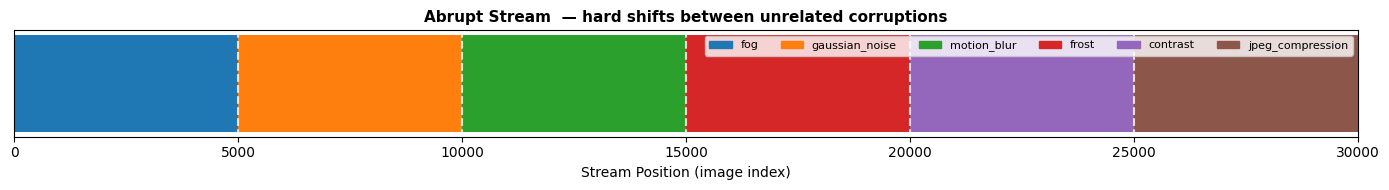

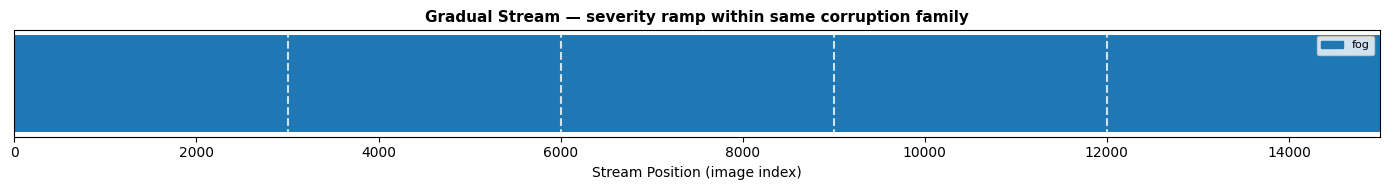

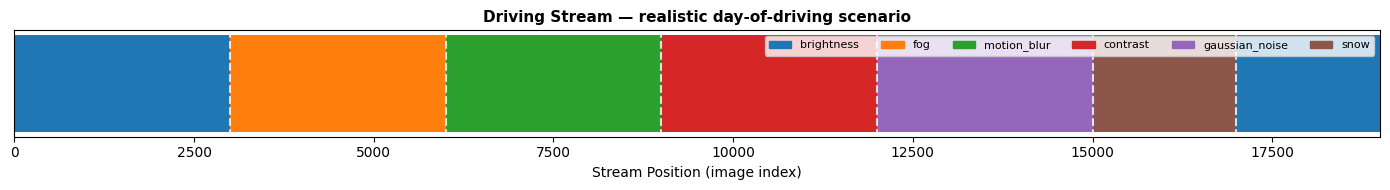

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_stream(csv_path, title):
    df = pd.read_csv(csv_path)
    corruptions = df['corruption'].unique().tolist()
    color_map = {c: plt.cm.tab10(i) for i, c in enumerate(corruptions)}

    fig, ax = plt.subplots(figsize=(14, 2))

    for _, row in df.iterrows():
        ax.barh(0, 1, left=row['position'], color=color_map[row['corruption']],
                height=0.5, linewidth=0)

    shifts = df[df['is_shift'] == 1]['position'].tolist()
    for s in shifts[1:]:
        ax.axvline(x=s, color='white', linewidth=1.5, linestyle='--', alpha=0.8)

    legend_patches = [mpatches.Patch(color=color_map[c], label=c) for c in corruptions]
    ax.legend(handles=legend_patches, loc='upper right', fontsize=8, ncol=len(corruptions))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Stream Position (image index)')
    ax.set_yticks([])
    ax.set_xlim(0, len(df))
    plt.tight_layout()
    plt.show()

plot_stream(abrupt_csv,  'Abrupt Stream  — hard shifts between unrelated corruptions')
plot_stream(gradual_csv, 'Gradual Stream — severity ramp within same corruption family')
plot_stream(driving_csv, 'Driving Stream — realistic day-of-driving scenario')

---
## Cell 8 — PyTorch Dataset Class
It reads from the stream CSV and serves images in order.

Key design decisions:
- `shuffle=False` **must** be enforced in the DataLoader — order is the entire point
- `is_shift` is returned so the evaluation loop can record SRT ground truth
- `label` is returned as a string class name; map to integer index using `class_to_idx`

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd

class SequentialStreamDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.df = pd.read_csv(csv_path).sort_values('position').reset_index(drop=True)

        unique_labels = sorted(self.df['label'].unique())
        self.class_to_idx = {c: i for i, c in enumerate(unique_labels)}
        self.idx_to_class = {i: c for c, i in self.class_to_idx.items()}

        self.transform = transform or transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std= [0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        img = self.transform(img)

        return {
            'image':      img,
            'label_idx':  torch.tensor(self.class_to_idx[row['label']], dtype=torch.long),
            'label_str':  row['label'],
            'corruption': row['corruption'],
            'severity':   int(row['severity']),
            'is_shift':   torch.tensor(int(row['is_shift']), dtype=torch.long),
            'position':   int(row['position']),
        }

dataset = SequentialStreamDataset(abrupt_csv)
loader  = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)
first_batch = next(iter(loader))
print('Smoke test passed ')

Smoke test passed 


---
## Cell 9 — SRT Metric Helper
Utility CAS evaluation loop calls after each stream run to compute Shift Recovery Time.

In [ ]:
import numpy as np

def compute_srt(accuracy_log, shift_positions, tau=0.80, pre_shift_window=50):
    positions = np.array([p for p, _ in accuracy_log])
    accuracies = np.array([a for _, a in accuracy_log])
    results = {}

    for shift_pos in shift_positions[1:]:
        pre_mask = (positions >= shift_pos - pre_shift_window) & (positions < shift_pos)
        if pre_mask.sum() == 0: continue
        baseline = accuracies[pre_mask].mean()
        target   = tau * baseline

        post_mask = positions > shift_pos
        post_positions  = positions[post_mask]
        post_accuracies = accuracies[post_mask]

        recovered = post_positions[post_accuracies >= target]
        srt = int(recovered[0] - shift_pos) if len(recovered) > 0 else None

        results[shift_pos] = {
            'baseline_acc': round(float(baseline), 4),
            'target_acc':   round(float(target), 4),
            'srt_batches':  srt
        }

    valid_srts = [v['srt_batches'] for v in results.values() if v['srt_batches'] is not None]
    results['mean_srt'] = round(float(np.mean(valid_srts)), 2) if valid_srts else None
    results['n_unrecovered'] = sum(1 for v in results.values() if isinstance(v, dict) and v['srt_batches'] is None)
    return results

dummy_log = [(i, 0.75 if i < 500 else max(0.4, 0.75 - 0.1*(i-500)/10 + 0.1*(i-500)/20)) for i in range(0, 1000, 10)]
dummy_shifts = [0, 500]
srt_result = compute_srt(dummy_log, dummy_shifts, tau=0.80)
print('SRT helper loaded')
print(f'Demo result: {srt_result}')

SRT helper loaded
Demo result: {500: {'baseline_acc': 0.75, 'target_acc': 0.6, 'srt_batches': 10}, 'mean_srt': 10.0, 'n_unrecovered': 0}


---
## Cell 10 — Final Summary
Lists all output files and confirms readiness for the CAS training loop.

In [ ]:
import os
import pandas as pd

print('='*55)
print('  STREAM BUILD COMPLETE')
print('='*55)

stream_files = [
    (abrupt_csv,  'Abrupt',  'SRT benchmark — hard shift recovery'),
    (gradual_csv, 'Gradual', 'Novelty term — slow drift detection'),
    (driving_csv, 'Driving', 'Full CAS — narrative validation'),
]

for path, name, purpose in stream_files:
    df   = pd.read_csv(path)
    size = os.path.getsize(path) / 1024
    print(f'\n  [{name}]')
    print(f'    File    : {path}')
    print(f'    Size    : {size:.1f} KB')
    print(f'    Images  : {len(df)}')
    print(f'    Shifts  : {df.is_shift.sum()}')
    print(f'    Purpose : {purpose}')



  STREAM BUILD COMPLETE

  [Abrupt]
    File    : /content/drive/MyDrive/DL_project/final_streams/stream_seed3/stream_abrupt_seed456.csv
    Size    : 3028.8 KB
    Images  : 30000
    Shifts  : 6
    Purpose : SRT benchmark — hard shift recovery

  [Gradual]
    File    : /content/drive/MyDrive/DL_project/final_streams/stream_seed3/stream_gradual_seed456.csv
    Size    : 1318.6 KB
    Images  : 15000
    Shifts  : 5
    Purpose : Novelty term — slow drift detection

  [Driving]
    File    : /content/drive/MyDrive/DL_project/final_streams/stream_seed3/stream_driving_seed456.csv
    Size    : 1886.0 KB
    Images  : 19000
    Shifts  : 7
    Purpose : Full CAS — narrative validation
